In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn import cluster
from sklearn import decomposition

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("Iris.csv")
data

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
data = data.drop("Id",axis=1)
data

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [5]:
data.shape

(150, 5)

In [6]:
data.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='str')

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
SepalLengthCm,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
SepalWidthCm,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
PetalLengthCm,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
PetalWidthCm,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


In [9]:
data.isnull().sum()

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(3)

In [11]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

In [12]:
le = preprocessing.LabelEncoder()
data["Species"] = le.fit_transform(data["Species"])
data["Species"]

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: Species, Length: 147, dtype: int64

In [13]:
x = data.drop("Species",axis=1)
x

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
y = data["Species"]

In [15]:
model_pca = decomposition.PCA(2)
x_2 = model_pca.fit_transform(x)
x_2

array([[-2.71078208,  0.32212528],
       [-2.74176333, -0.17506116],
       [-2.91669096, -0.14150943],
       [-2.77336298, -0.31520532],
       [-2.75541848,  0.33013256],
       [-2.30677001,  0.74421268],
       [-2.84828494, -0.08496501],
       [-2.65310892,  0.16596655],
       [-2.91498115, -0.5749113 ],
       [-2.70015083, -0.11204375],
       [-2.53285487,  0.64713841],
       [-2.64007217,  0.0178151 ],
       [-2.81378733, -0.23312816],
       [-3.25229701, -0.50705241],
       [-2.6695653 ,  1.18092174],
       [-2.41078938,  1.34178057],
       [-2.64938933,  0.81436131],
       [-2.67506711,  0.31488514],
       [-2.22523049,  0.87405982],
       [-2.61439438,  0.51729127],
       [-2.33656311,  0.3921208 ],
       [-2.57035205,  0.43673671],
       [-3.24327396,  0.13905262],
       [-2.33001796,  0.10116454],
       [-2.38310767, -0.03479638],
       [-2.53414463, -0.14482833],
       [-2.49602416,  0.13394912],
       [-2.58881821,  0.36989526],
       [-2.66614568,

How Does PCA Work? (Step-by-Step)                                                   
PCA converts a set of correlated high-dimensional features into a set of linearly uncorrelated values called Principal Components. It achieves this through the following steps:
1. Data Standardization (Feature Scaling)Since features are often measured in different units or scales, we first standardize the dataset so that each feature has a mean ($\mu$) of 0 and a standard deviation ($\sigma$) of 1.$$z = \frac{x - \mu}{\sigma}$$
2. Covariance Matrix ComputationNext, we compute the Covariance Matrix ($\Sigma$) to understand how the variables vary with respect to each other (i.e., identifying linear dependencies and correlations among features). For an $n \times p$ data matrix:$$\Sigma = \frac{1}{n-1} X^T X$$
3. Calculating Eigenvalues and EigenvectorsWe solve the characteristic equation of the covariance matrix to find its Eigenvalues ($\lambda$) and Eigenvectors ($v$):$$\Sigma v = \lambda v$$Eigenvectors ($v$): Define the directions of the new feature space (the principal components axes).Eigenvalues ($\lambda$): Represent the magnitude of variance retained along each corresponding eigenvector direction.
4. Selecting Principal ComponentsThe eigenvectors are ranked by their corresponding eigenvalues in descending order ($\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$).First Principal Component ($PC_1$): The eigenvector corresponding to the highest eigenvalue ($\lambda_1$), capturing the maximum variance in the data.Second Principal Component ($PC_2$): The eigenvector corresponding to the second highest eigenvalue ($\lambda_2$), which is completely orthogonal (perpendicular) to $PC_1$ and captures the next highest variance.To reduce dimensions from $p$ to $k$ ($k < p$), we select the top $k$ eigenvectors to construct a projection matrix $W_k$.

5. Projecting Data onto the New SpaceFinally, we transform the original feature space $X$ into the lower-dimensional subspace $Y$ by multiplying it with the projection matrix $W_k$:$$Y = X \cdot W_k$$

In [16]:
model_kmeans = cluster.KMeans(3)
y_pred = model_kmeans.fit_predict(x)
y_pred

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int32)

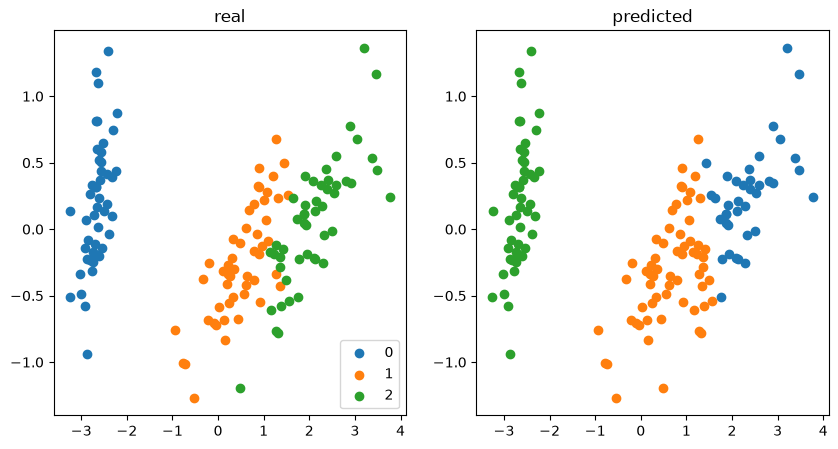

In [17]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(x_2[y==0,0] , x_2[y==0,1] , label="0")
plt.scatter(x_2[y==1,0] , x_2[y==1,1] , label="1")
plt.scatter(x_2[y==2,0] , x_2[y==2,1] , label="2")
plt.title("real")
plt.legend()

plt.subplot(1,2,2)
plt.scatter(x_2[y_pred==0,0] , x_2[y_pred==0,1])
plt.scatter(x_2[y_pred==1,0] , x_2[y_pred==1,1])
plt.scatter(x_2[y_pred==2,0] , x_2[y_pred==2,1])
plt.title("predicted")

plt.show()

In [18]:
print("▫️▫️▫️▫️▫️مرکز دسته ها▫️▫️▫️▫️")
print("-------before pca---------")
centers_4 = model_kmeans.cluster_centers_
print(centers_4)
print("-------after pca---------")
centers_2 = model_pca.transform(centers_4)
print(centers_2)

▫️▫️▫️▫️▫️مرکز دسته ها▫️▫️▫️▫️
-------before pca---------
[[6.85       3.07368421 5.74210526 2.07105263]
 [5.90327869 2.74918033 4.38196721 1.42622951]
 [5.01041667 3.43125    1.4625     0.25      ]]
-------after pca---------
[[ 2.34759566  0.25550069]
 [ 0.63555059 -0.3154685 ]
 [-2.66619211  0.1986365 ]]


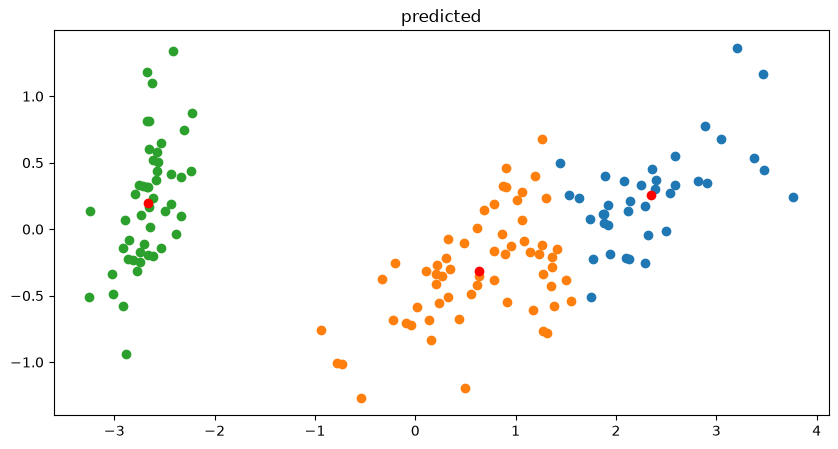

In [19]:
plt.figure(figsize=(10,5))
plt.scatter(x_2[y_pred==0,0] , x_2[y_pred==0,1])
plt.scatter(x_2[y_pred==1,0] , x_2[y_pred==1,1])
plt.scatter(x_2[y_pred==2,0] , x_2[y_pred==2,1])
plt.scatter(centers_2[0][0] , centers_2[0][1] , color="red")
plt.scatter(centers_2[1][0] , centers_2[1][1] , color="red")
plt.scatter(centers_2[2][0] , centers_2[2][1] , color="red")
plt.title("predicted")
plt.show()

In [20]:
x_new = [[5.0 , 3.6 , 1.4 , 0.2]]
y_new = model_kmeans.predict(x_new)
y_new

array([2], dtype=int32)

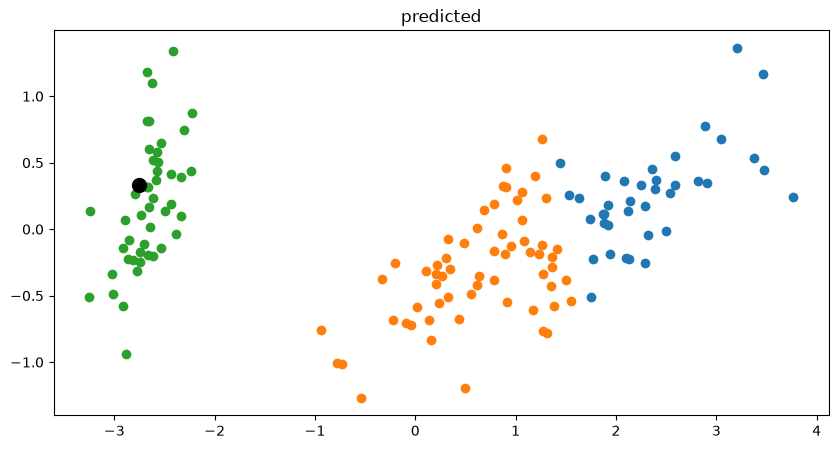

In [21]:
x_new_2 = model_pca.transform(x_new)

plt.figure(figsize=(10,5))
plt.scatter(x_2[y_pred==0,0] , x_2[y_pred==0,1])
plt.scatter(x_2[y_pred==1,0] , x_2[y_pred==1,1])
plt.scatter(x_2[y_pred==2,0] , x_2[y_pred==2,1])
plt.scatter(x_new_2[0][0] , x_new_2[0][1], s=100, color="black")
plt.title("predicted")
plt.show()